In [8]:
source(here::here("R/init.R"))

✔ Constants initialized successfully

✔ Libraries are loaded

✔ Fonts are loaded while configuring repr for 300dpi



In [12]:
df <- read_csv(here(config$DATA_FOLDER, config$SCOTOMA_DATA_FILE))
df <- df |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        PID = factor(PID)
    ) |>
    rename(
        building_location = inside,
        group = category
    )

Rows: 1829 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (4): PID, inside, GroupCount, median_clusterDuration

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [13]:
model <- glmer(median_clusterDuration ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df, Gamma(link = "inverse"))

In [14]:
# Create a reference grid
ref_grid <- ref_grid(model)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ group)

# View results
summary(emm)


,group,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,central,0.4004916,0.01403735,Inf,0.3729789,0.4280043
2,control,0.4331715,0.01687316,Inf,0.4001007,0.4662423
3,peripheral,0.4982905,0.02314886,Inf,0.4529195,0.5436614


In [15]:
# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ building_location)
# View results
summary(emm)



,building_location,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,outside,0.4089795,0.01269408,Inf,0.3840996,0.4338594
2,inside,0.4789896,0.02165684,Inf,0.4365429,0.5214362


In [16]:
df_node <- read_csv(here(config$DATA_FOLDER, config$SCOTOMA_NODE_FILE))

df_node <- df_node |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        hitObjectColliderName = factor(hitObjectColliderName),
        PID = factor(PID),
        category = factor(category, levels = c("peripheral", "central", "control"))
    ) |>
    rename(
        building_location = inside,
        group = category,
        building = hitObjectColliderName,
        duration = clusterDuration
    )


Rows: 17925 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (6): clusterID, sampleNr, clusterDuration, PID, inside, connections

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [17]:
df_group_node <- df_node |>
    group_by(PID, building, group, building_location, connections) |>
    summarise(median_duration = median(duration)) |>
    ungroup()

`summarise()` has grouped output by 'PID', 'building', 'group',
'building_location'. You can override using the `.groups` argument.


In [18]:
df_rm_null <- df_group_node |> filter(connections > 0)

model <- glmer(connections ~  group + building_location + (1 | PID), data = df_rm_null, Gamma(link = "inverse"))

In [19]:
# Create a reference grid
ref_grid <- ref_grid(model)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ group)

# View results
summary(emm)

,group,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,peripheral,5.119276,0.4476219,Inf,4.241953,5.996599
2,central,5.382336,0.4911143,Inf,4.419769,6.344902
3,control,6.355806,0.7004506,Inf,4.982949,7.728664


#### EMM Node and Dwell Time
**TODO**
**CONTINUE FROM HERE**

In [21]:
df_node <- read_csv(here(config$DATA_FOLDER, config$SCOTOMA_NODE_FILE))

df_node <- df_node |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        hitObjectColliderName = factor(hitObjectColliderName),
        PID = factor(PID),
        category = factor(category, levels = c("peripheral", "central", "control"))
    ) |>
    rename(
        building_location = inside,
        group = category,
        duration = clusterDuration
    ) |>
    group_by(PID, group, hitObjectColliderName, building_location) |>
    summarize(
        mean_connections = mean(connections)
    ) |>
    ungroup() |>
    filter(mean_connections > 0)

Rows: 17925 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (6): clusterID, sampleNr, clusterDuration, PID, inside, connections

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`summarise()` has grouped output by 'PID', 'group', 'hitObjectColliderName'.
You can override using the `.groups` argument.


In [22]:
df_node <- df_node %>% 
    mutate(
        group = factor(group, levels = c("control", "peripheral", "central"))
    )

In [23]:
model_0 <- glmer(median_clusterDuration ~ 1 + (1 | PID) + (1 | hitObjectColliderName), data = df, family = Gamma(link = "inverse"))
model_inter <- glmer(median_clusterDuration ~ building_location + (1 | PID) + (1 | hitObjectColliderName), data = df, family = Gamma(link = "inverse"))
df <- df %>% 
    mutate(
        group = factor(group, levels = c("control", "peripheral", "central"))
    )
model_full <- glmer(median_clusterDuration ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df, family = Gamma(link = "inverse"))

In [24]:
node_model_0 <- glmer(mean_connections ~ 1 + (1 | PID) + (1 | hitObjectColliderName), data = df_node, family = poisson())
node_model_inter <- glmer(mean_connections ~ building_location + (1 | PID) + (1 | hitObjectColliderName), data = df_node, family = poisson())

node_model_full <- glmer(mean_connections ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df_node, family = poisson())
     

In [35]:
# Create a reference grid
ref_grid <- ref_grid(model_full)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ group)
emm_building <- emmeans(new_grid, ~ building_location)
emm_eff <- emmeans(model_full, ~ group)
emm_building_eff <- emmeans(model_full, ~ building_location)

VarCorr(model_full)
full_var <- as_tibble(VarCorr(model_full)) %>% pull(sdcor)
full_sd <- sqrt(sum(full_var^2))
eff_size(emm_eff, sigma = full_sd, edf = 1822)

# View results
summary(emm, level = 0.95)
emm_table_pairs <- pairs(emm, adjust = "tukey") %>% summary()
pairs(emm, adjust = "tukey")

summary(emm_building)
pairs(emm_building, adjust = "tukey")
r2_nakagawa(model_full)
r2_nakagawa(node_model_full)

 Groups                Name        Std.Dev.
 hitObjectColliderName (Intercept) 0.28454 
 PID                   (Intercept) 0.12020 
 Residual                          0.36876 

 contrast             effect.size    SE  df asymp.LCL asymp.UCL
 control - peripheral       0.623 0.198 Inf     0.234   1.01144
 control - central         -0.390 0.195 Inf    -0.771  -0.00782
 peripheral - central      -1.012 0.197 Inf    -1.399  -0.62566

Results are averaged over the levels of: building_location 
sigma used for effect sizes: 0.481 
Confidence level used: 0.95 

,group,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,control,0.4331712,0.01687345,Inf,0.4000999,0.4662426
2,peripheral,0.4982853,0.02314907,Inf,0.4529139,0.5436566
3,central,0.4004901,0.01403756,Inf,0.3729770,0.4280032


 contrast             estimate     SE  df z.ratio p.value
 control - peripheral  -0.0651 0.0216 Inf  -3.013  0.0073
 control - central      0.0327 0.0166 Inf   1.972  0.1191
 peripheral - central   0.0978 0.0210 Inf   4.646  <.0001

Results are averaged over the levels of: building_location 
P value adjustment: tukey method for comparing a family of 3 estimates 

,building_location,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,outside,0.4089780,0.01269419,Inf,0.3840978,0.4338581
2,inside,0.4789864,0.02165684,Inf,0.4365398,0.5214330


 contrast         estimate     SE  df z.ratio p.value
 outside - inside    -0.07 0.0207 Inf  -3.376  0.0007

Results are averaged over the levels of: group 

# R2 for Mixed Models

  Conditional R2: 0.549
     Marginal R2: 0.233

# R2 for Mixed Models

  Conditional R2: 0.715
     Marginal R2: 0.290

In [26]:
df <- df %>% 
    mutate(
        group = factor(group, levels = c("central", "control", "peripheral"))
    )
model_full_emm <- glmer(median_clusterDuration ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df, family = Gamma(link = "inverse"))


ref_grid_emm <- ref_grid(model_full_emm)
custom_emm_table <- emm_table_pairs %>%
    rename(p = p.value) %>%
    mutate(
        group1 = c("control", "control", "peripheral"),
        group2 = c("peripheral", "central", "central"),
        label = c("**", "P = 0.11", "***"),
        y.position = c(0.80, 0.75, 0.85)
    )


dwell_time_fig <- ref_grid_emm %>% emmip(~ group, CIs = TRUE, type = "response", style="factor") +
  geom_violin(aes(y = median_clusterDuration, x = group), alpha = 0.2, data = df)+ 
  labs(
    title = "EMM(s) of Dwell Time",
    x = "Group",
    y = "Dwell Time (s)",
  ) +
  add_pvalue(custom_emm_table, tip.length = 0) +
  scale_x_discrete(expand = c(0,.5)) +
  scale_y_continuous(lim = c(0,1), expand = c(0,0)) 


In [27]:
df_node <- df_node %>% 
    mutate(
        group = factor(group, levels = c("central", "control", "peripheral"))
    )
node_model_full_emm <- glmer(mean_connections ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df_node, family = Gamma(link = "inverse"))

In [28]:
node_ref_grid_emm <- ref_grid(node_model_full_emm)
ndc_mean_fig <- node_ref_grid_emm %>% emmip(~ group, CIs = TRUE, type = "response", style="factor") +
  geom_violin(aes(y = mean_connections, x = group), alpha = 0.2, data = df_node)+ 
  labs(
    title = "EMM(s) of NDC",
    x = "Group",
    y = "NDC"
  ) +
  scale_x_discrete(expand = c(0,.5)) +
  scale_y_continuous(lim = c(0, 20), expand = c(0,0))

In [34]:
# Create a reference grid
ref_grid <- ref_grid(node_model_full_emm)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ group)
emm_eff <- emmeans(node_model_full_emm, ~ group)
eff_size(emm_eff, sigma = sigma(node_model_full_emm)*sqrt(2), edf = df.residual(model))

# View results
summary(emm)
pairs(emm, adjust = "tukey")
r2_nakagawa(node_model_full_emm)


 contrast             effect.size     SE  df asymp.LCL asymp.UCL
 central - control         0.0438 0.0385 Inf   -0.0317   0.11936
 central - peripheral     -0.0233 0.0378 Inf   -0.0973   0.05077
 control - peripheral     -0.0671 0.0385 Inf   -0.1426   0.00849

Results are averaged over the levels of: building_location 
sigma used for effect sizes: 0.6216 
Confidence level used: 0.95 

,group,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,central,3.836439,0.4727036,Inf,2.909957,4.762921
2,control,4.371498,0.6515589,Inf,3.094466,5.648530
3,peripheral,3.606621,0.4098208,Inf,2.803387,4.409855


 contrast             estimate    SE  df z.ratio p.value
 central - control      -0.535 0.504 Inf  -1.062  0.5375
 central - peripheral    0.230 0.379 Inf   0.607  0.8163
 control - peripheral    0.765 0.502 Inf   1.523  0.2801

Results are averaged over the levels of: building_location 
P value adjustment: tukey method for comparing a family of 3 estimates 

# R2 for Mixed Models

  Conditional R2: 0.100
     Marginal R2: 0.071

In [30]:
# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ building_location)
emm_eff <- emmeans(node_model_full_emm, ~ building_location)
eff_size(emm_eff, sigma = sigma(node_model_full_emm)*sqrt(2), edf = df.residual(model))

# View results
summary(emm)
pairs(emm, adjust = "tukey")
r2_nakagawa(model)

 contrast         effect.size     SE  df asymp.LCL asymp.UCL
 outside - inside       0.393 0.0515 Inf     0.292     0.494

Results are averaged over the levels of: group 
sigma used for effect sizes: 0.6216 
Confidence level used: 0.95 

,building_location,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,outside,2.347044,0.1181907,Inf,2.115394,2.578693
2,inside,5.529328,0.8636406,Inf,3.836624,7.222033


 contrast         estimate    SE  df z.ratio p.value
 outside - inside    -3.18 0.849 Inf  -3.749  0.0002

Results are averaged over the levels of: group 

# R2 for Mixed Models

  Conditional R2: 0.008
     Marginal R2: 0.006

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Warning message:
“Removed 55 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 7 rows containing non-finite outside the scale range
(`stat_ydensity()`).”


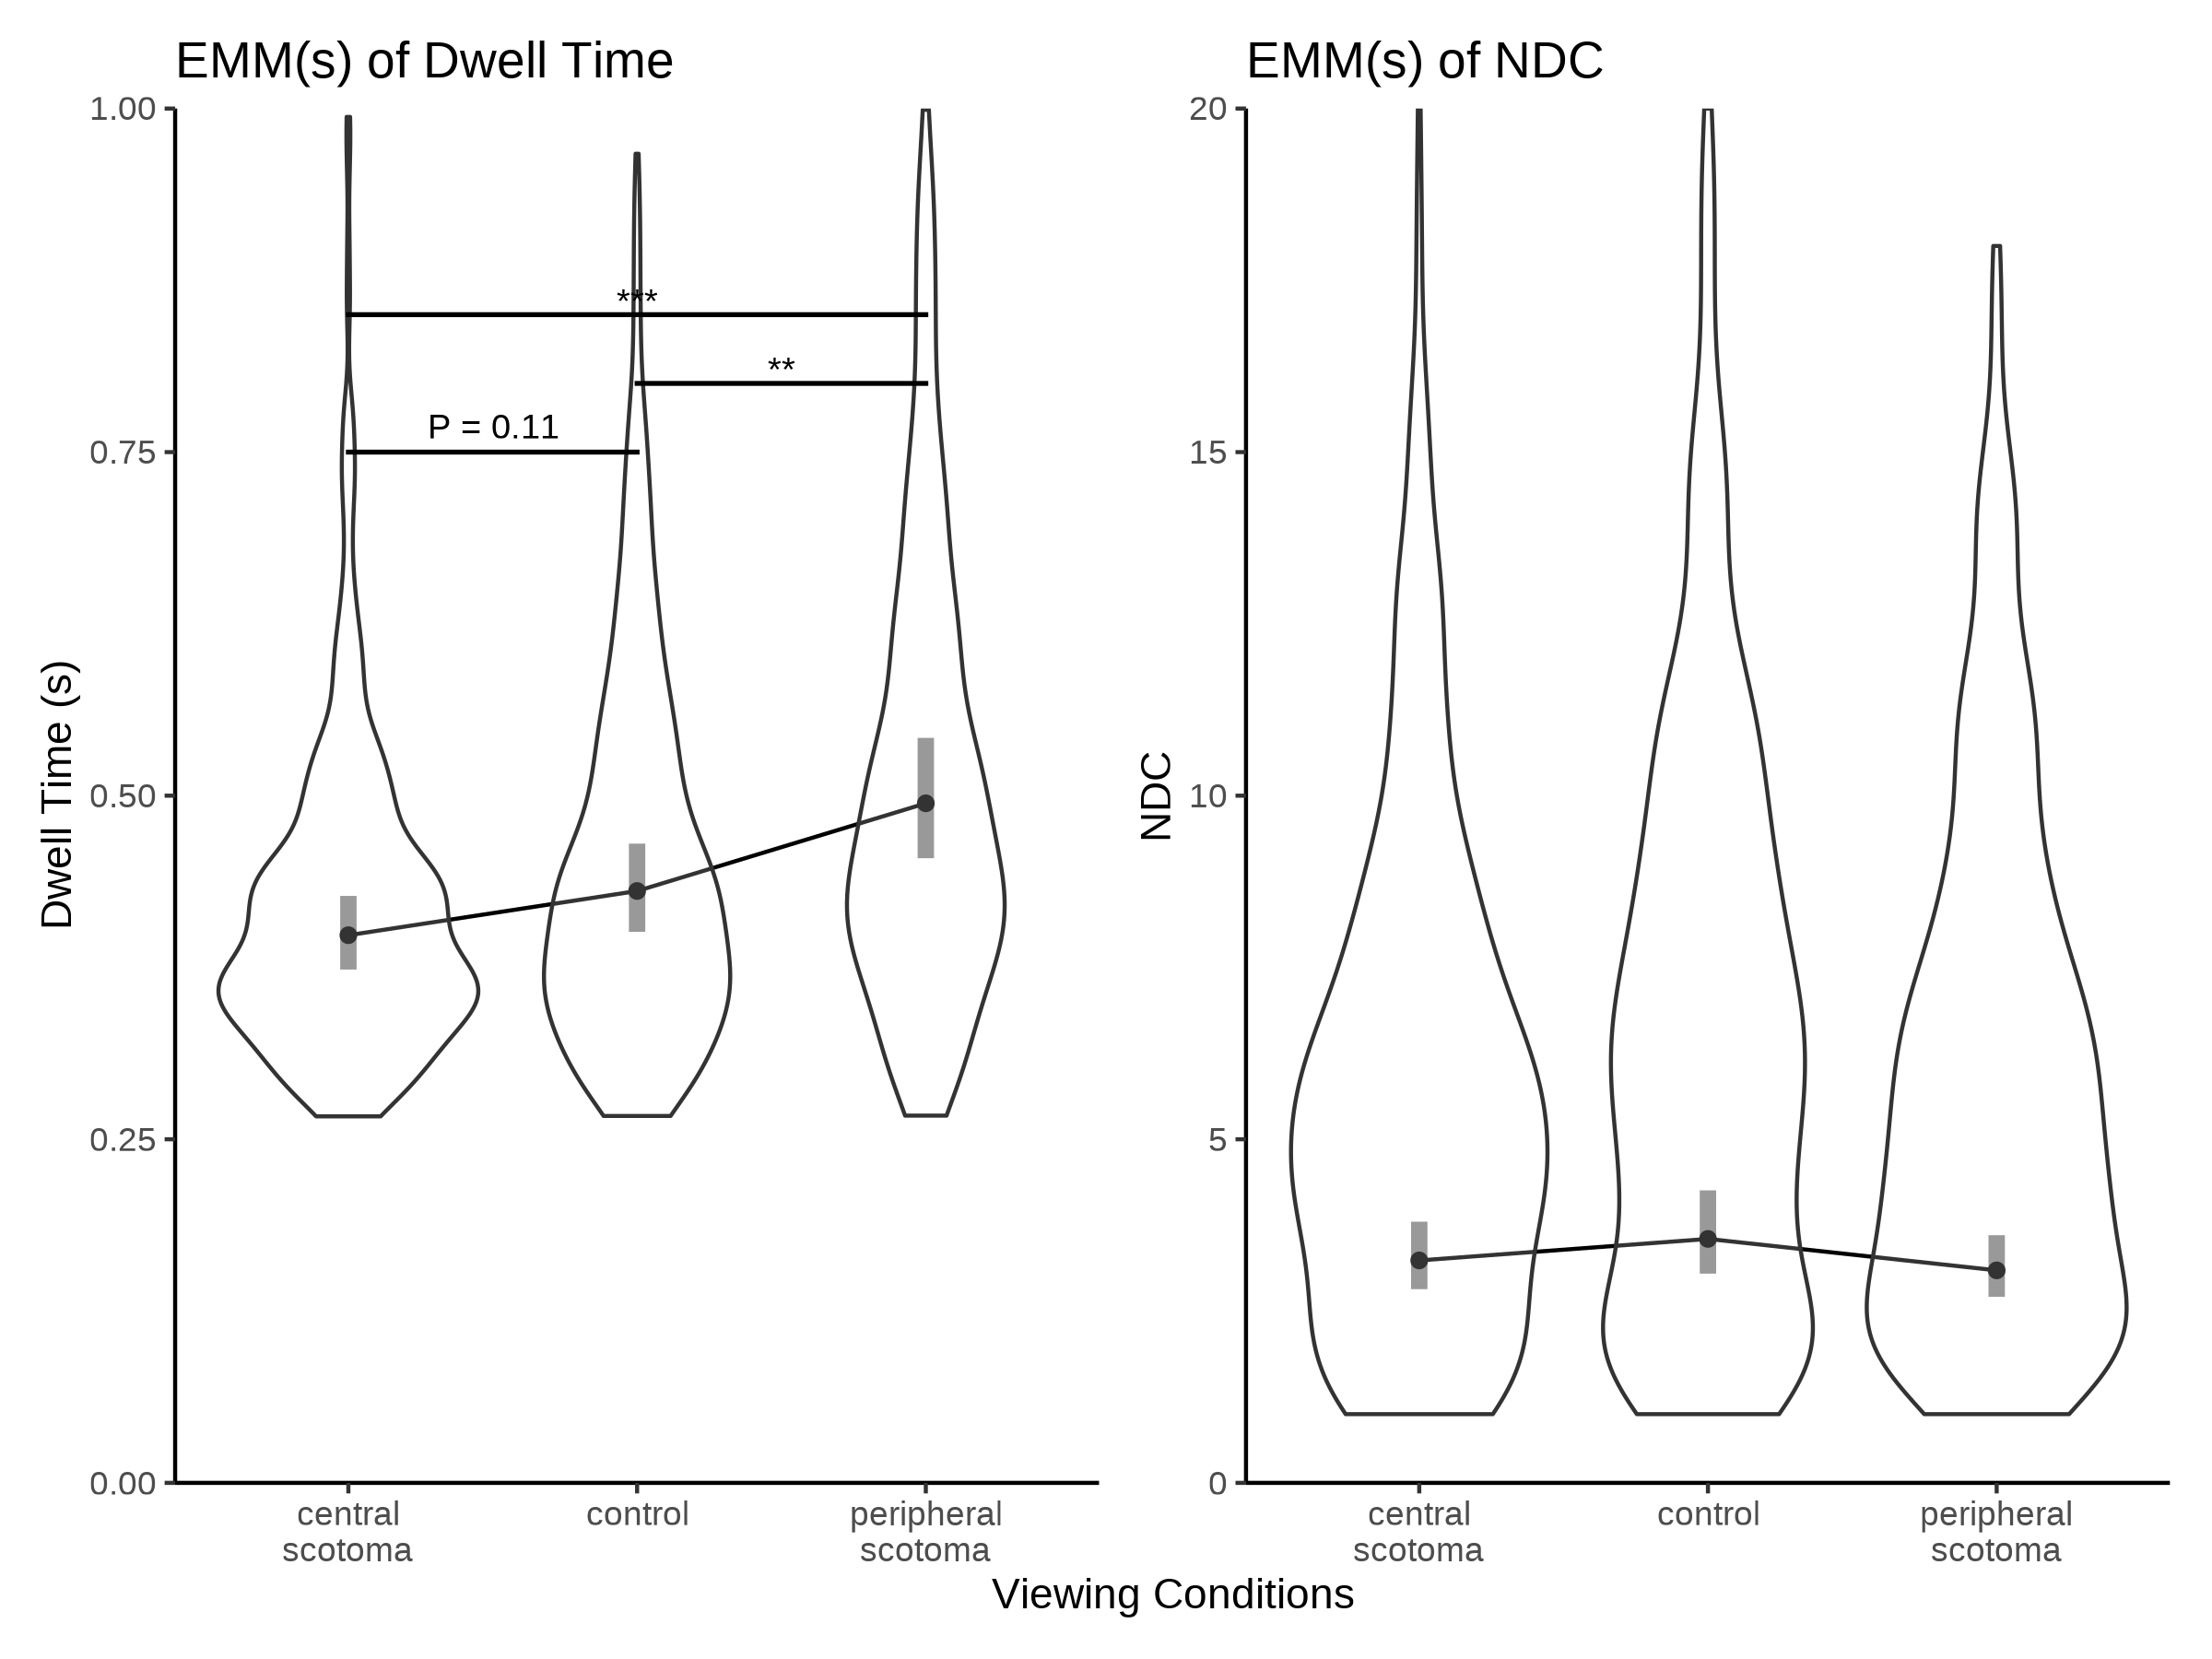

In [31]:

(
    dwell_time_fig + 
    ndc_mean_fig + 
    plot_layout(guides = 'collect', axis_titles = 'collect')
) & 
scale_x_discrete(labels = c("central" = "central\nscotoma", "control" = "control", "peripheral" = "peripheral\nscotoma")) &
xlab("Viewing Conditions") & 
(
    theme_classic() + 
    theme(legend.position = "none")
)


#### Model Summary

In [36]:
source(here::here("R", "utils.R"))

In [37]:
dwell_time_model_summaries <- get_sim_model_summary(model_0, model_inter, model_full)
node_model_summaries <- get_sim_model_summary(node_model_0, node_model_inter, node_model_full)

#### GT Table Generation

In [38]:
dt <- tibble(
    model_name = c(
        "**LRT**",
        "***fixed effects***",
        "intercept",
        "region (inside)",
        "condition (peripheral)",
        "condition (central)",
        "***random effects***",
        "building",
        "participant",
        "observation-level<br>&nbsp;&nbsp;(distribution-specific)",
        "$R^2_{GLMM(m)}$ (%)",
        "$R^2_{GLMM(c)}$ (%)",
        "$ICC_{[Building]}$ (%)",
        "$ICC_{[Participant]}$ (%)",
        "$AIC$"
    ),
    # dwell time models
    dw_null_model = dwell_time_model_summaries$model_null,
    dw_inter_model = dwell_time_model_summaries$model_inter_summary,
    dw_full_model = dwell_time_model_summaries$model_full_summary,
    # node models
    node_null_model = node_model_summaries$model_null,
    node_inter_model = node_model_summaries$model_inter_summary,
    node_full_model = node_model_summaries$model_full_summary
)

dt %>% gt() %>% 
  tab_spanner(
    label = md("**Dwell Time Models (inverse-link)<br>Gamma Mixed Models**"),
    columns = starts_with("dw"),
    id = "dwell_time_models"
  ) %>%
  tab_spanner(
    label = md("**NDC Models (log-link)<br>Poisson Mixed Models**"),
    columns = starts_with("node")
  ) %>%
  cols_label(
    model_name = md("**Model Name**"),
    dw_null_model = md("**Null Model**"),
    dw_inter_model = md("**Intermediate Model**"),
    dw_full_model = md("**Full Model**"),
    node_null_model = md("**Null Model**"),
    node_inter_model = md("**Intermediate Model**"),
    node_full_model = md("**Full Model**")
  ) %>%
  tab_style(
    style = cell_borders(
      sides = c("right", "left"),
      color = "black",
      weight = px(2)
    ),
    locations = cells_column_spanners(
      "dwell_time_models"
    )
  ) %>%
  tab_style(
    style = cell_borders(
      sides = "right",
      color = "black",
      weight = px(2)
    ),
    locations = cells_column_labels(
      "dw_full_model"
    )
  ) %>%
   tab_style(
    style = cell_borders(
      sides = "right",
      color = "black",
      weight = px(2)
    ),
    locations = cells_body(
      "dw_full_model"
    )
  ) %>%
  tab_style(
    style = cell_borders(
      sides = "left",
      color = "black",
      weight = px(2)
    ),
    locations = cells_column_labels(
      "dw_null_model"
    )
  ) %>%
   tab_style(
    style = cell_borders(
      sides = "left",
      color = "black",
      weight = px(2)
    ),
    locations = cells_body(
      "dw_null_model"
    )
  ) %>%
  cols_width(everything() ~ px(200)) %>%
  fmt_markdown() %>%
  #gtsave("model_summaries.html")
  capture.output() %>% 
  IRdisplay::display_html()


Model Name 
 
 Dwell Time Models (inverse-link) Gamma Mixed Models 
 
 
 NDC Models (log-link) Poisson Mixed Models 
 
 
 
 Null Model 
 Intermediate Model 
 Full Model 
 Null Model 
 Intermediate Model 
 Full Model 
 
 
 
 LRT 
 — 
 
 χ 2 ( 1 ) \chi^2(1) χ 2 ( 1 ) = 13.49, 
 p p p < .001*** 
 
 χ 2 ( 2 ) \chi^2(2) χ 2 ( 2 ) = 14.99, 
 p p p < .001*** 
 — 
 
 χ 2 ( 1 ) \chi^2(1) χ 2 ( 1 ) = 66.55, 
 p p p < .001*** 
 
 χ 2 ( 2 ) \chi^2(2) χ 2 ( 2 ) = 2.96, 
 p p p = 0.23 
 fixed effects 
 b [95% CI] 
 b [95% CI] 
 b [95% CI] 
 b [95% CI] 
 b [95% CI] 
 b [95% CI] 
 intercept 
 2.418 [2.242, 2.595] 
 2.511 [2.33, 2.692] 
 2.499 [2.318, 2.68] 
 1.315 [1.151, 1.479] 
 1.037 [0.872, 1.201] 
 1.171 [0.953, 1.39] 
 region (inside) 
 — 
 -0.355 [-0.544, -0.167] 
 -0.354 [-0.543, -0.166] 
 — 
 0.868 [0.677, 1.059] 
 0.868 [0.677, 1.059] 
 condition (peripheral) 
 — 
 — 
 -0.3 [-0.486, -0.113] 
 — 
 — 
 -0.211 [-0.47, 0.048] 
 condition (central) 
 — 
 — 
 0.187 [0.004, 0.371] 
 — 
 — 
 -0.193 [-0.452, 0.065] 
 random effects 
 
 σ 2 \sigma^2 σ 2 
 
 σ 2 \sigma^2 σ 2 
 
 σ 2 \sigma^2 σ 2 
 
 σ 2 \sigma^2 σ 2 
 
 σ 2 \sigma^2 σ 2 
 
 σ 2 \sigma^2 σ 2 
 building 
 0.093 
 0.082 
 0.081 
 0.393 
 0.221 
 0.221 
 participant 
 0.031 
 0.032 
 0.014 
 0.077 
 0.077 
 0.067 
 observation-level   (distribution-specific) 
 0.139 
 0.137 
 0.136 
 — 
 — 
 — 
 
 R G L M M ( m ) 2 R^2_{GLMM(m)} R G L MM ( m ) 2 ​ (%) 
 — 
 11.19 
 23.31 
 — 
 27.8 
 28.96 
 
 R G L M M ( c ) 2 R^2_{GLMM(c)} R G L MM ( c ) 2 ​ (%) 
 — 
 51.45 
 54.93 
 — 
 71.61 
 71.54 
 
 I C C [ B u i l d i n g ] ICC_{[Building]} I C C [ B u i l d in g ] ​ (%) 
 35.32 
 32.62 
 34.99 
 59.32 
 45.05 
 45.91 
 
 I C C [ P a r t i c i p a n t ] ICC_{[Participant]} I C C [ P a r t i c i p an t ] ​ (%) 
 11.94 
 12.72 
 6.24 
 11.63 
 15.63 
 14.02 
 
 A I C AIC A I C 
 -1843 
 -1854.5 
 -1865.5 
 8263.3 
 8198.8 
 8199.8